<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Hyperparameter_Tuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =====================================
# 🚀 Percepatan & Pengukuran Eksekusi
# =====================================

# 1️⃣ --- Cek apakah GPU aktif di Colab ---
import os
gpu_info = os.popen('nvidia-smi').read()
if "failed" in gpu_info:
    print("⚠️ GPU belum aktif. Aktifkan via Runtime > Change runtime type > GPU")
else:
    print("✅ GPU aktif dan siap dipakai!")
    print(gpu_info.split('\n')[0])

# 2️⃣ --- Cara 1: Pakai %%time (khusus untuk cell di Colab) ---
# Jalankan ini di satu cell Colab terpisah:
# %%time
# for i in range(10_000_000):
#     _ = i ** 2

# 3️⃣ --- Cara 2: Pakai time.time() manual ---
import time

print("\n⏱️ Mengukur waktu dengan time.time() ...")
start = time.time()
for i in range(10_000_000):
    _ = i ** 2
end = time.time()
print(f"Waktu eksekusi loop biasa: {end - start:.3f} detik")

# 4️⃣ --- Cara 3: Pakai Numba (JIT Compiler) untuk mempercepat Python loop ---
from numba import njit

@njit
def fast_loop(n=10_000_000):
    total = 0
    for i in range(n):
        total += i ** 2
    return total

print("\n⚡ Mengukur waktu dengan Numba (JIT Compilation)...")
start = time.time()
fast_loop()  # pertama kali akan kompilasi (lebih lambat)
end = time.time()
print(f"Pertama kali (kompilasi): {end - start:.3f} detik")

start = time.time()
fast_loop()  # eksekusi berikutnya super cepat
end = time.time()
print(f"Eksekusi berikutnya: {end - start:.3f} detik")

# 5️⃣ --- Cara 4: Gunakan operasi vectorized (NumPy) ---
import numpy as np

print("\n⚙️ Mengukur waktu dengan operasi vectorized NumPy ...")
start = time.time()
x = np.arange(10_000_000)
y = x ** 2  # super cepat tanpa loop manual
end = time.time()
print(f"Waktu eksekusi NumPy: {end - start:.3f} detik")

# 6️⃣ --- Bonus: Decorator otomatis untuk mengukur waktu fungsi ---
def timed(func):
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        end = time.time()
        print(f"⏰ Fungsi '{func.__name__}' selesai dalam {end - start:.3f} detik")
        return result
    return wrapper

@timed
def contoh_fungsi():
    s = 0
    for i in range(5_000_000):
        s += i ** 2
    return s

print("\n🧩 Contoh fungsi dengan decorator otomatis:")
contoh_fungsi()

✅ GPU aktif dan siap dipakai!


⏱️ Mengukur waktu dengan time.time() ...
Waktu eksekusi loop biasa: 2.518 detik

⚡ Mengukur waktu dengan Numba (JIT Compilation)...
Pertama kali (kompilasi): 2.016 detik
Eksekusi berikutnya: 0.000 detik

⚙️ Mengukur waktu dengan operasi vectorized NumPy ...
Waktu eksekusi NumPy: 0.066 detik

🧩 Contoh fungsi dengan decorator otomatis:
⏰ Fungsi 'contoh_fungsi' selesai dalam 0.517 detik


41666654166667500000

**Import Library**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

**Load Dataset**

In [3]:
df = pd.read_csv("penjualan.csv")
print(df.head())

   Harga  Stok  Diskon  Rating  Terjual
0  23795    21       5     3.1        1
1   8860    42      12     4.9        1
2  13390    28      19     4.7        1
3  29575    73      29     3.7        0
4  19964    74      14     4.9        1


**Pisahkan Fitur dan Label**

In [4]:
X = df[['Harga', 'Stok', 'Diskon', 'Rating']]
y = df['Terjual']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Standarisasi Data**

In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# Catatan: KNN sensitif terhadap skala fitur, jadi standarisasi penting agar semua fitur punya rentang nilai yang seimbang.

**Model Awal (Tanpa Tuning)**

In [7]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)

print("Akurasi Awal:", accuracy_score(y_test, y_pred))

Akurasi Awal: 0.525


**Hyperparameter Tuning dengan Grid Search**

In [8]:
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score (CV):", grid_search.best_score_)

Best Parameters: {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}
Best Score (CV): 0.6125


**Evaluasi Model Terbaik**

In [9]:
best_knn = grid_search.best_estimator_
y_pred_best = best_knn.predict(X_test_scaled)

print("Akurasi Akhir:", accuracy_score(y_test, y_pred_best))
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred_best))

Akurasi Akhir: 0.625

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.81      0.61      0.69        28
           1       0.42      0.67      0.52        12

    accuracy                           0.62        40
   macro avg       0.62      0.64      0.61        40
weighted avg       0.69      0.62      0.64        40



**Visualisasi Pengaruh Parameter terhadap Akurasi**

In [10]:
results = pd.DataFrame(grid_search.cv_results_)

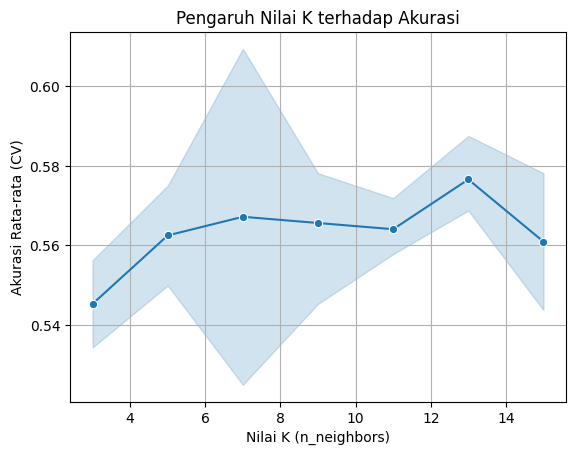

In [11]:
# --- Visualisasi 1: Pengaruh Nilai K ---
sns.lineplot(x=results["param_n_neighbors"], y=results["mean_test_score"], marker='o')
plt.title("Pengaruh Nilai K terhadap Akurasi")
plt.xlabel("Nilai K (n_neighbors)")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.grid(True)
plt.show()

/tmp/ipython-input-1570604163.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=results["param_weights"], y=results["mean_test_score"], ci=None)


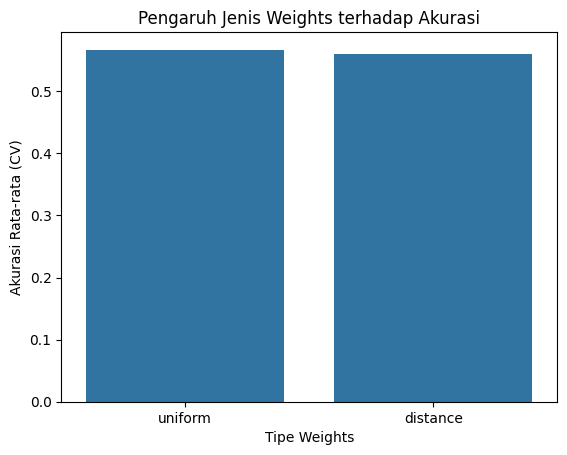

In [12]:
# --- Visualisasi 2: Pengaruh Weights ---
sns.barplot(x=results["param_weights"], y=results["mean_test_score"], ci=None)
plt.title("Pengaruh Jenis Weights terhadap Akurasi")
plt.xlabel("Tipe Weights")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.show()

/tmp/ipython-input-1900426390.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=results["param_metric"], y=results["mean_test_score"], ci=None)


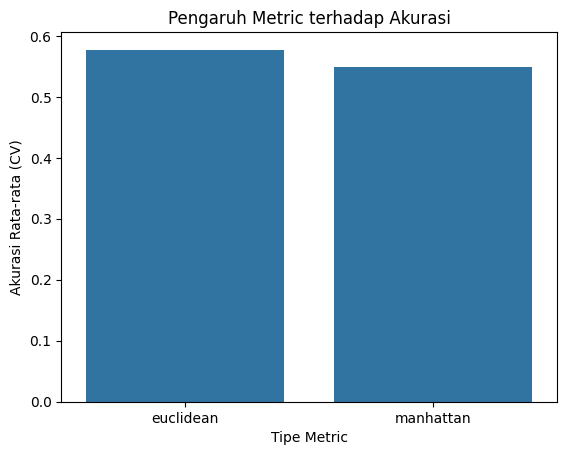

In [13]:
# --- Visualisasi 3: Pengaruh Metric ---
sns.barplot(x=results["param_metric"], y=results["mean_test_score"], ci=None)
plt.title("Pengaruh Metric terhadap Akurasi")
plt.xlabel("Tipe Metric")
plt.ylabel("Akurasi Rata-rata (CV)")
plt.show()

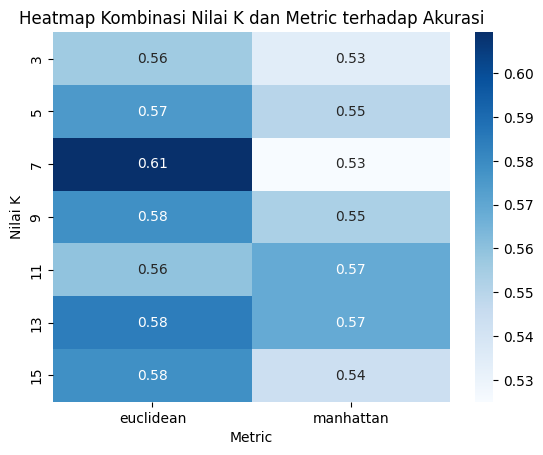

In [14]:
# --- Visualisasi 4: Kombinasi Nilai K dan Metric (Heatmap) ---
pivot_table = results.pivot_table(
    values='mean_test_score',
    index='param_n_neighbors',
    columns='param_metric'
)

sns.heatmap(pivot_table, annot=True, cmap="Blues")
plt.title("Heatmap Kombinasi Nilai K dan Metric terhadap Akurasi")
plt.xlabel("Metric")
plt.ylabel("Nilai K")
plt.show()

**Analisis Parameter Paling Berpengaruh terhadap Akurasi**

/tmp/ipython-input-22315625.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Pengaruh (Δ Akurasi)', y='Parameter', data=df_influence, palette="viridis")


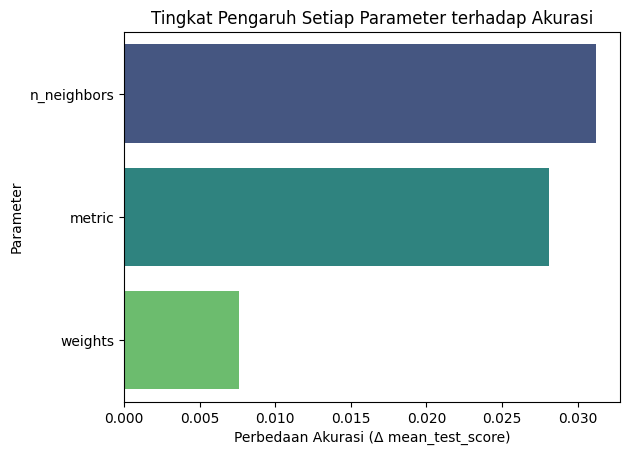

     Parameter  Pengaruh (Δ Akurasi)
0  n_neighbors              0.031250
2       metric              0.028125
1      weights              0.007589


In [16]:
influence = []

for param in ['param_n_neighbors', 'param_weights', 'param_metric']:
    impact = results.groupby(param)['mean_test_score'].mean().max() - results.groupby(param)['mean_test_score'].mean().min()
    influence.append({'Parameter': param.replace('param_', ''), 'Pengaruh (Δ Akurasi)': impact})

df_influence = pd.DataFrame(influence).sort_values(by='Pengaruh (Δ Akurasi)', ascending=False)

sns.barplot(x='Pengaruh (Δ Akurasi)', y='Parameter', data=df_influence, palette="viridis")
plt.title("Tingkat Pengaruh Setiap Parameter terhadap Akurasi")
plt.xlabel("Perbedaan Akurasi (Δ mean_test_score)")
plt.ylabel("Parameter")
plt.show()

print(df_influence)